In [7]:
# !pip install skrebate

In [8]:
# =========================
# 1. 라이브러리
# =========================
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from skrebate import MultiSURF

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, recall_score

# =========================
# 2. 데이터 불러오기
# =========================
data = pd.read_csv(r"../../data/processed/data_vif.csv")

# Date 시간순 정렬 보장
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date").reset_index(drop=True)

# 혹시 남아있을 경우 방어적으로 제거
data = data.drop(columns=["return_t1(%)"], errors="ignore")

target_col = "Risk_Label"
date_col = "Date"

if target_col not in data.columns:
    raise ValueError(f"{target_col} 컬럼이 없습니다.")

if date_col not in data.columns:
    raise ValueError(f"{date_col} 컬럼이 없습니다.")

# =========================
# Signal 기준범주 Stay 복원
# MultiSURF 거리계산용
# =========================

signal_prefixes = ["Signal1", "Signal2", "Signal3", "Signal4"]

for sig in signal_prefixes:
    buy_col = f"{sig}_Buy"
    sell_col = f"{sig}_Sell"
    stay_col = f"{sig}_Stay"
    
    if buy_col in data.columns and sell_col in data.columns and stay_col not in data.columns:
        data[stay_col] = (
            (data[buy_col] == 0) & (data[sell_col] == 0)
        ).astype(int)

print([col for col in data.columns if "Signal" in col])

# =========================
# 3. Label을 0/1로 변환
# =========================
label_norm = data['Risk_Label'].astype(str).str.strip().str.lower()

label_map = {
    'low risk': 0,
    'high risk': 1,
    '0': 0,
    '1': 1
}

data['Risk_Label'] = label_norm.map(label_map)

# 변환 실패한 값 확인
if data['Risk_Label'].isna().sum() > 0:
    print("변환 실패한 Risk_Label 값:")
    print(data.loc[data['Risk_Label'].isna(), 'Risk_Label'].unique())
    raise ValueError("Risk_Label 변환 실패")

data['Risk_Label'] = data['Risk_Label'].astype(int)

print(data['Risk_Label'].value_counts())

['Signal1_Buy', 'Signal1_Sell', 'Signal2_Buy', 'Signal2_Sell', 'Signal3_Buy', 'Signal3_Sell', 'Signal4_Buy', 'Signal4_Sell', 'Signal1_Stay', 'Signal2_Stay', 'Signal3_Stay', 'Signal4_Stay']
Risk_Label
0    3617
1     491
Name: count, dtype: int64


In [9]:
# =========================
# 4. train:valid:test = 45:35:20 시간순 분할
# =========================
n = len(data)

train_end = int(n * 0.45)
valid_end = int(n * 0.8)

data_train = data[:train_end].copy()
data_valid = data[train_end:valid_end].copy()
data_test = data[valid_end:].copy()

# =========================
# 5. X, y 분리
# =========================
X_train = data_train.drop(['Risk_Label', 'Date'], axis=1)
y_train = data_train['Risk_Label']

X_valid = data_valid.drop(['Risk_Label', 'Date'], axis=1)
y_valid = data_valid['Risk_Label']

X_test = data_test.drop(['Risk_Label', 'Date'], axis=1)
y_test = data_test['Risk_Label']

# =========================
# 모든 설명변수가 숫자형인지 확인
# =========================
non_numeric_cols = (
    X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    + X_valid.select_dtypes(exclude=[np.number]).columns.tolist()
    + X_test.select_dtypes(exclude=[np.number]).columns.tolist()
)

non_numeric_cols = sorted(set(non_numeric_cols))

if len(non_numeric_cols) > 0:
    raise ValueError(f"숫자형이 아닌 컬럼이 있습니다: {non_numeric_cols}")

print("모든 설명변수가 숫자형입니다.")

# =========================
# 7. Scaling
# =========================
# 논문 흐름에 맞추려면 MinMaxScaler
scaler = MinMaxScaler()

# 이상치 압축 문제가 걱정되면 아래로 바꿔서 비교 가능
# scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=X_valid.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

모든 설명변수가 숫자형입니다.


In [10]:
# =========================
# 8. MultiSURF 변수선택
# =========================
fs = MultiSURF(
    n_features_to_select=X_train_scaled.shape[1],
    n_jobs=-1
)

fs.fit(X_train_scaled.values, y_train.values)

importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': fs.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df

,feature,importance
0,NASDAQ_return(%),0.093623
1,Brent Crude Oil_return(%),0.028805
2,Gold Spot_return(%),0.024575
3,KOSPI 200 lagged_1_return(%),0.017164
4,KOSPI 200_BB_width,0.010905
5,VKOSPI_Change(%),0.009251
6,KOSDAQ_return(%),0.008741
7,KOSPI 200_ADX14,0.008407
8,VKOSPI_Close,0.007263
9,return(%),0.005309


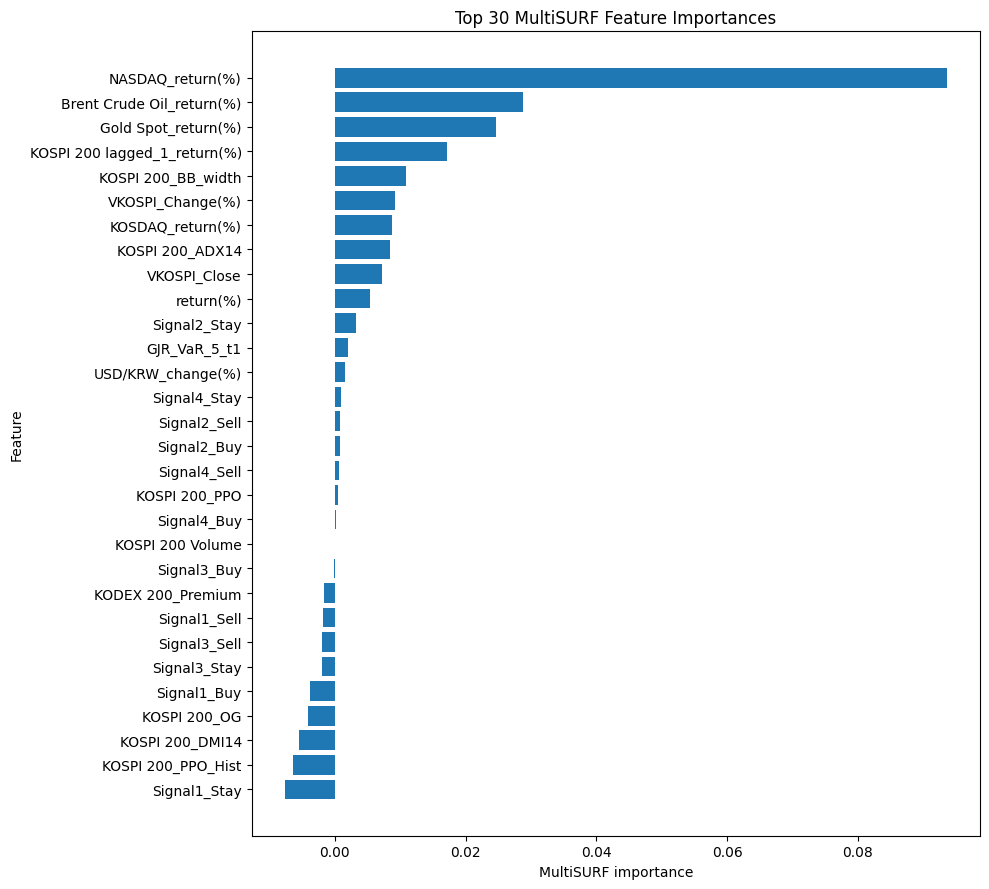

In [11]:
# =========================
# 9. 중요도 시각화
# =========================
plot_df = importance_df.head(30).sort_values('importance')

plt.figure(figsize=(10, max(6, len(plot_df) * 0.3)))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.xlabel("MultiSURF importance")
plt.ylabel("Feature")
plt.title("Top 30 MultiSURF Feature Importances")
plt.tight_layout()
plt.show()

In [12]:
# =========================================
# 10. MultiSURF 상위변수 중요도의 1% 미만 변수 제거
#     Signal 계열 변수가 하나라도 선택되면 Buy/Sell 둘 다 포함
# =========================================

importance_threshold = importance_df['importance'].iloc[0] * 0.01

# 1차: 중요도 기준 통과 변수
raw_selected_features = importance_df.loc[
    importance_df['importance'] >= importance_threshold,
    'feature'
].tolist()

# 전체 사용 가능한 변수 목록
available_features = set(importance_df['feature'].tolist())

# Signal 그룹 정의
signal_prefixes = ["Signal1", "Signal2", "Signal3", "Signal4"]

# 최종 변수 리스트
final_features = []

for feature in raw_selected_features:
    # Signal 계열이면 일단 여기서 바로 넣지 않고 그룹 단위로 처리
    if feature.startswith("Signal"):
        continue
    final_features.append(feature)

# Signal 계열 처리
for sig in signal_prefixes:
    signal_group_cols = [f"{sig}_Buy", f"{sig}_Sell", f"{sig}_Stay"]
    
    # raw_selected_features 안에 해당 Signal 그룹 변수가 하나라도 있으면
    if any(col in raw_selected_features for col in signal_group_cols):
        buy_col = f"{sig}_Buy"
        sell_col = f"{sig}_Sell"
        
        # Buy/Sell 둘 다 최종 변수에 포함
        if buy_col in available_features:
            final_features.append(buy_col)
        if sell_col in available_features:
            final_features.append(sell_col)

# 중복 제거하면서 순서 유지
final_features = list(dict.fromkeys(final_features))

selected_features = final_features

print(f'1등 변수 중요도: {importance_df["importance"].iloc[0]:.6f}')
print(f'제거 기준(1%): {importance_threshold:.6f}')
print(f'1차 선택 변수 개수: {len(raw_selected_features)}')
print(f'최종 남길 변수 개수: {len(final_features)}')
print(final_features)

1등 변수 중요도: 0.093623
제거 기준(1%): 0.000936
1차 선택 변수 개수: 13
최종 남길 변수 개수: 14
['NASDAQ_return(%)', 'Brent Crude Oil_return(%)', 'Gold Spot_return(%)', 'KOSPI 200 lagged_1_return(%)', 'KOSPI 200_BB_width', 'VKOSPI_Change(%)', 'KOSDAQ_return(%)', 'KOSPI 200_ADX14', 'VKOSPI_Close', 'return(%)', 'GJR_VaR_5_t1', 'USD/KRW_change(%)', 'Signal2_Buy', 'Signal2_Sell']
